# Artificial neural networks using Keras and Tensorflow

We will use [TensorFlow](https://www.tensorflow.org/) which is a free and open-source software library for machine learning and artificial intelligence. Its main focus is on training and inference of deep neural networks.

More specifically, we will use [Keras](https://keras.io/) which is an open-source software library that acts as an interface for the TensorFlow library.

[PyTorch](https://pytorch.org/) also allows you to work with artificial neural networks with Python. You may want to have a look yourself.

To start with, make sure you have TensorFlow installed in your Python distribution. This can be achieved with the instruction

`> python3 -m pip install --upgrade tensorflow`

in the anaconda propt environment (or directly on a prompt shell if you are using Linux).

We now import some basic libraries and the libraries for `tensorflow` and `keras`:

In [1]:
import numpy as np  # mathematical functions, random number generators, linear algebra routines, Fourier transforms, and more
import pandas as pd  # data analysis and manipulation tool
import matplotlib.pyplot as plt  #  static, animated, and interactive data visualizations
import seaborn as sns  # data visualization library based on matplotlib

import warnings  
warnings.filterwarnings('ignore')  # ignore warnings

import tensorflow as tf
from tensorflow import keras

In [2]:
# One can check the tensorflow version 
tf.__version__

'2.8.0'

We will use the MNIST fashion data set (https://keras.io/api/datasets/)

Visualization of Keras datasets: https://machinelearningmastery.com/how-to-load-and-visualize-standard-computer-vision-datasets-with-keras/ 

This is a dataset of 60,000 28x28 grayscale images of 10 fashion categories, along with a test set of 10,000 images. This dataset can be used as a drop-in replacement for MNIST.

The classes (and labels) are: 0-T-shirt/top, 1-Trouser, 2-Pullover, 3-Dress, 4-Coat, 5-Sandal, 6-Shirt, 7-Sneaker, 8-Bag, 9-Ankle boot

In [91]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [92]:
X_train_full

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

The data comes already split into train and test datasets:

In [93]:
# summarize loaded dataset
print('Train: X=%s, y=%s' % (X_train_full.shape, y_train_full.shape))
print('Test: X=%s, y=%s' % (X_test.shape, y_test.shape))

Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


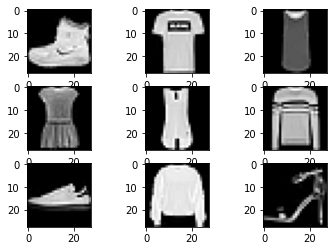

In [6]:
# plot first few images
for i in range(9):
 # define subplot
 plt.subplot(330 + 1 + i)
 # plot raw pixel data
 plt.imshow(X_train_full[i], cmap=plt.get_cmap('gray'))

Before training a neural network for classification, we do the following:
* We split the train dataset into 55,000 examples that are used for training and the rest, 5,000 examples, are used for validation during the training process.
* Must scale the input features. In particular, we scale the pixel intensities down to the 0-1 range by dividing them by 255.0 (this also converts them to floats)

In [7]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

For example, the first example of the training dataset is

In [8]:
y_train[0]

4

We give names to each class label to convert class numbers to objects:

In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [10]:
class_names[y_train[0]]

'Coat'

## Classification - Image Classifier 

We will use Keras to build a relatively simple ANN for image classification using the MNIST-fashion dataset

### Building the model

The `Sequential` function allows a model to be built.

One can create the model and add the layers one by one

In [11]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

Alternatively, one can add the layers within the `Sequential` function:

In [12]:
# Creating the model as a sequence
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

The model consists of four layers:

* A `Flatten` layer: Converts any input image into a 1D array. For input data `X`, it computes `X.reshape(-1, 1)`. The input shape has to be specified (image of size 28x28 pixels). Otherwise, this layer has no parameters.
* A hidden `Dense` layer with 100 neurons using a `relu` activation function. Dense implements the operation: `output = activation(dot(input, kernel) + bias)` where `activation` is the element-wise activation function passed as the activation argument, `kernel` is a weights matrix created by the layer, and `bias` is a bias vector created by the layer (only applicable if use_bias is True).
* Another `Dense` layer with 100 neurons.
* A `softmax` layer to obtain the probability for the input to belong to each of the 10 classes in the dataset. If we were doing binary classification, we would use `sigmoid` instead of `softmax`.

The parameters of the models can be summarised:

In [13]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 100)               78500     
                                                                 
 dense_4 (Dense)             (None, 100)               10100     
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 89,610
Trainable params: 89,610
Non-trainable params: 0
_________________________________________________________________


In [14]:
model.layers

In [15]:
model.layers[1].name

'dense_3'

In [16]:
# Keras also provides a function to create a plot of the network neural network graph that can make more complex models easier to understand.
from keras.utils.vis_utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model/model_to_dot to work.


One can access the weights and biases of a layer with `get_weights`

In [17]:
# For the first Dense layer
weights1, biases1 = model.layers[1].get_weights()

In [18]:
# The weights were initialized randomly
weights1

array([[-0.03301266,  0.04248449, -0.06754711, ..., -0.02463337,
        -0.07516387,  0.02979524],
       [-0.02830815, -0.07890869,  0.06665647, ..., -0.02732782,
         0.02921465, -0.05118464],
       [-0.00291996,  0.07288182, -0.0642207 , ..., -0.06400342,
         0.02334891, -0.05198066],
       ...,
       [ 0.07169692,  0.06559204,  0.07560562, ...,  0.04747751,
         0.04716328,  0.03462729],
       [ 0.06116512,  0.0665414 , -0.06072395, ..., -0.04692019,
         0.05660844,  0.05165808],
       [ 0.05035658, -0.04924443,  0.07232681, ...,  0.01452254,
         0.00321236, -0.04342561]], dtype=float32)

In [19]:
# The length of the weights array corresponds to the input 
# For each of the inputs, there are 300 neurons
print(weights1.shape)

# There are as many biases as inputs to the layer
print(biases1.shape)

(784, 100)
(100,)


In [20]:
# For the second Dense layer, there are 300 inputs and 100 neurons (outputs)
weights2, biases2 = model.layers[2].get_weights()
print(weights2.shape)
print(biases2.shape)

(100, 100)
(100,)


### Compiling the model

We use the `compile` Keras function:

In [22]:
model.compile(loss="sparse_categorical_crossentropy",
optimizer="sgd",
metrics=["accuracy"])

We need to specify the following:
* Loss: `sparse_categorical_crossentropy` since we are dealing with sparse labels for classes (an integer for each class).  If we had encoded each class by an array (e.g. [0,1,0,1] for class 7), we would need the loss function `categorical_crossentropy`. If we were doing binary classification, we would need `binary_crossentropy`.
* Optimizer to minimise the loss function: Backpropagation with the Stochastic Gradient Descent method (`sgd`). For example, you can try other optimization methods such as the Adaptive Moment Estimation (Adam) method setting this to `adam`.
* We will measure the accuracy of the classifier during training and evaluation.

### Training and evaluating the model

* We pass the training data to the model
* Specify the number of epochs for training (the number of times the algorithm scans the entire training data). Intuitively, the algorithm needs to see the data several times to learn it. Each epoch consists of a number of iterations that look at "smaller" batches of the data.
* We pass validation data to the model. This is optional but advisable to check for potential overfitting (i.e. cases in which the model fits very well the training data but fails to predict the previously unseen data (the validation data here).

In [28]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

Epoch 1/50
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3413 - accuracy: 0.8787 - val_loss: 0.3454 - val_accuracy: 0.8764
Epoch 2/50
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3334 - accuracy: 0.8807 - val_loss: 0.3454 - val_accuracy: 0.8744
Epoch 3/50
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3265 - accuracy: 0.8837 - val_loss: 0.3419 - val_accuracy: 0.8818
Epoch 4/50
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3197 - accuracy: 0.8850 - val_loss: 0.3397 - val_accuracy: 0.8796
Epoch 5/50
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3138 - accuracy: 0.8870 - val_loss: 0.3493 - val_accuracy: 0.8734
Epoch 6/50
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3074 - accuracy: 0.8892 - val_loss: 0.3500 - val_accuracy: 0.8748
Epoch 7/50
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3020 - accuracy: 0.8905 - val_loss: 0.3528 - val_accuracy:

Plot for the accuracy and loss functions for the training and validation datasets:

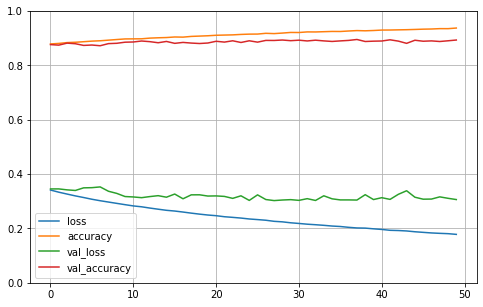

In [29]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

The network is trained. Note the following:
* The loss kept decreasing. This means that the model is becoming closer to the training data. Since the accuracy seems to be still decreasing after 30 epochs, one could try training with more epochs.
* In this particular training run, the validation loss is clearly above the training loss, meaning that there is some overfitting... This means that the data used for training is well fit but generalisation to the validation dataset is not so good.

Let us evaluate the performance of the model for the **test dataset** using the `evaluate` function which takes the features and labels of the test dataset as arguments:

In [30]:
eval1 = model.evaluate(X_test, y_test)

print('Loss:', eval1[0]) 
print('Accuracy:', eval1[1])

313/313 [==============================] - 1s 2ms/step - loss: 97.9506 - accuracy: 0.8073
Loss: 97.9505844116211
Accuracy: 0.8072999715805054


Not too bad! As expected, the performance was slightly better for the validation dataset since the model hyperparameters were tuned using the validation set. However, considering the fact that the test dataset was completely unseen by the ANN before, the performance is reasonable. 

### Using the model

We use the `predict()` function to make predictions on unseen instances. This gives the probability that an example is classified as each of the classes.

In [31]:
y_proba = model.predict(X_test[:10])
#y_proba.round(2)
#y_proba

In [32]:
y_proba

array([[0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 7.71702e-19, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00

One can get the predicted class by taking the class with maximum probability for each example and transforming from class number to class name:

In [41]:
# The predicted class
y_pred = np.argmax(y_proba,axis=1) #Position of the element with highest probability
y_pred_name = np.array(class_names)[y_pred]
#y_pred = model.predict_classes(X_test[0])

In [42]:
y_pred_name

array(['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'T-shirt/top',
       'Trouser', 'Coat', 'Shirt', 'Sandal', 'Sneaker'], dtype='<U11')

The true classes are:

In [43]:
y_true_name = np.array(class_names)[y_test[:10]]

In [44]:
y_true_name

array(['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser',
       'Coat', 'Shirt', 'Sandal', 'Sneaker'], dtype='<U11')

A datafrema with the predicted and true classes:

In [45]:
pd.DataFrame({'True class': y_true_name, 'Predicted class': y_pred_name})

,True class,Predicted class
0,Ankle boot,Ankle boot
1,Pullover,Pullover
2,Trouser,Trouser
3,Trouser,Trouser
4,Shirt,T-shirt/top
5,Trouser,Trouser
6,Coat,Coat
7,Shirt,Shirt
8,Sandal,Sandal
9,Sneaker,Sneaker


In [51]:
pd.DataFrame(y_true_name==y_pred_name).value_counts()

True     9
False    1
dtype: int64

One can make predictions for all the examples in the dataset at once:

In [52]:
y_proba_All = model.predict(X_test)

y_pred_All = np.argmax(y_proba_All,axis=1) #Position of the element with highest probability
y_pred_All_name = np.array(class_names)[y_pred_All]
y_true_name_All = np.array(class_names)[y_test]

pd.DataFrame(y_pred_All==y_test).value_counts()

True     8073
False    1927
dtype: int64

From this one could easily calculate the accuracy and error of the classifier

#### Task for you 1

A strategy to minimise overfitting during ANN training is to use dropout layers. These layers randomly set input units to 0 with a frequency of rate, $r$, at each step during training time, which helps prevent overfitting. Inputs not set to 0 are scaled up by $1/(1 - r)$ such that the sum over all inputs is unchanged. In intuitive terms, by dropping some input values every time the training process goes through the network, the model learns the training data in a less perfect manner.

Insert a `Dropout` layer with rate $r=0.2$ in the model defined above to try an improve the overfitting when training on the MNIST data as done above. Compare the training and validation losses. Did the network become more accurate?

## Regression neural network

California housing dataset. Using only numerical features.

In [94]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

# Splitting the dataset into (full) training and testing datasets
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
# Splitting the full training dataset into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [95]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [96]:
housing['feature_names']

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [97]:
housing['target']

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [98]:
housing['DESCR']

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n    :Number of Instances: 20640\n\n    :Number of Attributes: 8 numeric, predictive attributes and the target\n\n    :Attribute Information:\n        - MedInc        median income in block group\n        - HouseAge      median house age in block group\n        - AveRooms      average number of rooms per household\n        - AveBedrms     average number of bedrooms per household\n        - Population    block group population\n        - AveOccup      average number of household members\n        - Latitude      block group latitude\n        - Longitude     block group longitude\n\n    :Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000

In [99]:
X_train.shape[1:]

(8,)

### ANN with three layers

In [100]:
model_reg = keras.Sequential()

model_reg.add(keras.layers.Dense(8, activation="relu", input_shape=X_train.shape[1:]))
model_reg.add(keras.layers.Dense(8, activation="relu"))
model_reg.add(keras.layers.Dense(1))

model_reg.compile(optimizer="adam", loss="mean_squared_error")

In [101]:
model_reg.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 8)                 72        
                                                                 
 dense_22 (Dense)            (None, 8)                 72        
                                                                 
 dense_23 (Dense)            (None, 1)                 9         
                                                                 
Total params: 153
Trainable params: 153
Non-trainable params: 0
_________________________________________________________________


In [102]:
model_reg.layers[0].get_weights()

[array([[ 0.33309072, -0.50223327, -0.60615486,  0.05280477, -0.07019496,
         -0.3097139 ,  0.50090533, -0.19776925],
        [ 0.5216512 , -0.5464796 , -0.6039428 , -0.0491569 ,  0.4864903 ,
         -0.1704782 ,  0.2683581 , -0.47144997],
        [ 0.6015925 ,  0.4242323 ,  0.34229034, -0.17579365, -0.03619438,
          0.22111422,  0.4325704 , -0.55653554],
        [-0.22539046, -0.10570234,  0.4512319 ,  0.20555651, -0.19380432,
          0.5629129 ,  0.174927  , -0.05855089],
        [-0.20860648, -0.23661852,  0.38707632,  0.14647311,  0.05032378,
          0.2492997 , -0.2933812 , -0.42577243],
        [-0.5527099 ,  0.1145671 , -0.60715115, -0.345073  , -0.58837926,
         -0.09743094, -0.13603348, -0.27045396],
        [ 0.36583507,  0.6009528 ,  0.32116956,  0.05373067, -0.17731848,
          0.46116143,  0.30249476, -0.29059318],
        [-0.36298454,  0.50571257,  0.4740681 , -0.5903571 ,  0.33658653,
          0.20774257, -0.540725  ,  0.58050555]], dtype=float32),

We can now train the network. Note that I use early stopping here to stop the training once the minimisation of the loss has stopped improving. I set a `patience` of 5 to stop once the loss optimisation does not improve after 5 epochs.

In [103]:
history_reg = model_reg.fit(X_train, y_train, epochs=30,validation_data=(X_valid, y_valid), callbacks = [keras.callbacks.EarlyStopping(patience = 5)])

Epoch 1/30
363/363 [==============================] - 1s 2ms/step - loss: 30433.9902 - val_loss: 295.9018
Epoch 2/30
363/363 [==============================] - 1s 1ms/step - loss: 232.2580 - val_loss: 106.8798
Epoch 3/30
363/363 [==============================] - 1s 2ms/step - loss: 70.4045 - val_loss: 17.3090
Epoch 4/30
363/363 [==============================] - 1s 1ms/step - loss: 16.5664 - val_loss: 6.1045
Epoch 5/30
363/363 [==============================] - 1s 1ms/step - loss: 7.4430 - val_loss: 4.7829
Epoch 6/30
363/363 [==============================] - 1s 1ms/step - loss: 5.0607 - val_loss: 1.5904
Epoch 7/30
363/363 [==============================] - 1s 1ms/step - loss: 2.1579 - val_loss: 1.5105
Epoch 8/30
363/363 [==============================] - 1s 1ms/step - loss: 1.3313 - val_loss: 1.6168
Epoch 9/30
363/363 [==============================] - 1s 1ms/step - loss: 1.2315 - val_loss: 1.4345
Epoch 10/30
363/363 [==============================] - 1s 2ms/step - loss: 1.2047 - val

In [104]:
pd.DataFrame(history_reg.history)

,loss,val_loss
0,30433.990234,295.901794
1,232.257996,106.879807
2,70.404465,17.309013
3,16.566359,6.104456
4,7.443038,4.782911
5,5.060725,1.590446
6,2.157917,1.510502
7,1.331297,1.616850
8,1.231533,1.434479
9,1.204713,1.427404


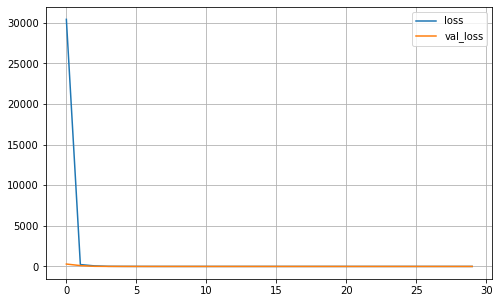

In [105]:
pd.DataFrame(history_reg.history).plot(figsize=(8, 5))
plt.grid(True)

#### Comparison of the predicted and true values:

In [106]:
#X_new = X_test # pretend these are new instances
y_pred = model_reg.predict(X_test)

Text(0, 0.5, 'Actual value')

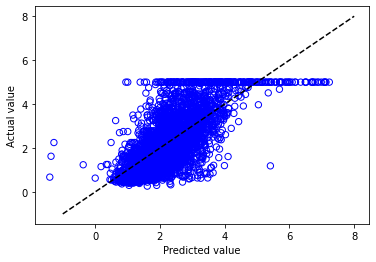

In [107]:
plt.scatter(y_pred[:,0],y_test, s=40, facecolors='none', edgecolors='b')
x = np.linspace(-1, 8, 10)
plt.plot(x,x,'--k')
plt.xlabel('Predicted value')
plt.ylabel('Actual value')
#plt.xlim([-1,8])
#plt.ylim([-1,8])

Text(0, 0.5, 'Residual (actual - predicted)')

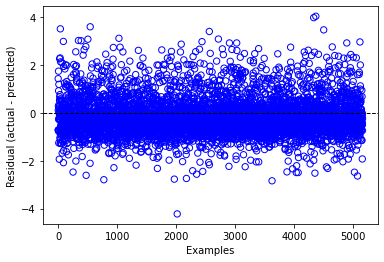

In [108]:
residuals = np.subtract(y_test,y_pred[:,0])
plt.scatter(range(len(residuals)),residuals, s=40, facecolors='none', edgecolors='b')
plt.axhline(y = 0, color = 'black', ls='--', lw=1, label = 'axvline - full height')
#x = np.linspace(-1, 8, 10)
#plt.plot(x,x,'--k')
plt.xlabel('Examples')
plt.ylabel('Residual (actual - predicted)')

In [109]:
# Statistics of the residuals
pd.DataFrame(residuals).describe()

,0
count,5160.000000
mean,-0.156577
std,0.792536
min,-4.224719
25%,-0.650678
50%,-0.284456
75%,0.198479
max,4.051399


## Using pre-trained neural networks - ResNet50

Keras offers a set of pre-trained neural networks (see https://keras.io/api/applications/). 

Here, we will load the [ResNet50](https://arxiv.org/abs/1512.03385) which is a neural network trained to identify the main object in an image. We will use its version trained on the [ImageNet competition data](https://image-net.org/challenges/LSVRC/2012/). It can classify into 1,000 different object classes.


### Loading and exploring the model

In [110]:
from tensorflow.keras.applications.resnet50 import ResNet50

model_RN50 = ResNet50(weights='imagenet')

102981632/102967424 [==============================] - 15s 0us/step


In [111]:
#Number of layers
len(model_RN50.layers)

177

In [112]:
print(model_RN50.get_layer(index=1))
print(model_RN50.layers[1])

### Using the model to classify images

We load the image of a lion and transform it to the size 224x224 required by the ResNet50 model.

In [113]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

img_path = 'Data/lion.jpg'
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

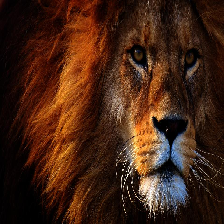

In [114]:
# Transformed image
img

In [115]:
# The preprocessed image is an array of 224x224 pixels in RGB color format
# Each pixel consists of 3 numbers [red,green,blue]
x.shape

(1, 224, 224, 3)

Make a prediction for the lion picture

This requires predicting the output for `x` and then decoding the prediction to find an image. 

Here, we output the three most likely classes by setting `top=3`

In [116]:
preds = model_RN50.predict(x)
# decode the results into a list of tuples (class, description, probability)
# (one such list for each sample in the batch)
print('Predicted:', decode_predictions(preds, top=3)[0])
# Predicted: [(u'n02504013', u'Indian_elephant', 0.82658225), (u'n01871265', u'tusker', 0.1122357), (u'n02504458', u'African_elephant', 0.061040461)]


49152/35363 [=========================================] - 0s 2us/step
Predicted: [('n02129165', 'lion', 0.7995736), ('n02480495', 'orangutan', 0.19316845), ('n02112137', 'chow', 0.0028678335)]


In [124]:
preds[0]

array([1.60316802e-10, 3.04222758e-09, 8.61284946e-08, 1.82669844e-08,
       1.40608869e-09, 1.39882701e-08, 1.26802121e-07, 3.43457003e-07,
       8.00377933e-08, 4.60626737e-08, 1.57151177e-07, 1.89227336e-08,
       1.32412069e-07, 4.04211598e-08, 3.15082040e-08, 1.56499311e-08,
       3.78476317e-09, 1.11174373e-07, 2.59686139e-08, 2.67284918e-07,
       7.33990158e-09, 1.47324588e-08, 1.63574683e-08, 4.24447997e-08,
       4.37183928e-07, 1.35849971e-08, 1.16608492e-08, 1.16585142e-08,
       4.69678660e-08, 4.61804417e-09, 4.74091300e-09, 1.49680019e-08,
       2.00968255e-08, 1.58925317e-08, 2.45711185e-08, 4.34266356e-09,
       4.87522982e-08, 6.58941746e-09, 9.48689571e-09, 4.96183645e-08,
       7.08400734e-08, 6.05685457e-09, 1.19999115e-07, 6.39814652e-06,
       5.23135313e-09, 1.45687951e-08, 1.83914057e-08, 8.03670996e-09,
       1.44200323e-08, 4.80838594e-07, 9.34204181e-09, 1.43646908e-08,
       1.64727110e-09, 1.61718638e-08, 3.62130486e-08, 1.25173312e-08,
      

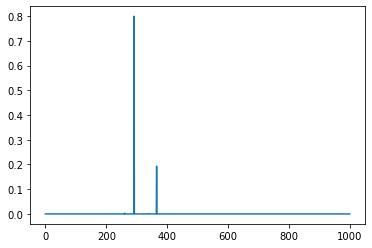

In [122]:
plt.plot(preds[0])

Lion came as the most likely class!!